## Notebook to create LEE coincidence templates from Run57 data

In [1]:
import os
import numpy as np

import darklim

from darklim.sensitivity._random_sampling import pdf_sampling

from scipy.special import factorial
import scipy.stats as stats
import scipy.special as special
from scipy import integrate, interpolate

import matplotlib.pyplot as plt
if None != os.getenv('NERSC_HOST'):
    import matplotlib.font_manager as font_manager
    font_manager.fontManager.addfont('/global/cfs/cdirs/lz/physics/WS/SR1/msttcorefonts/Times_New_Roman.ttf')

import matplotlib
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = 'Times New Roman'

from matplotlib.ticker import AutoMinorLocator, MultipleLocator, FixedLocator, FuncFormatter, MaxNLocator

from multihist import Hist1d

%matplotlib inline

In [2]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx, array[idx]

def find_nearest_floor(array, value):
    array = np.asarray(array)
    #idx = (np.floor(np.abs(array - value))).argmin()
    idx = array.searchsorted(value, 'right') - 1
    return idx, array[idx]

def pdf_integral(pdf,e_low,e_high,npts):
    '''
    assumes 'pdf' is a lambda function
    '''
    en_interp = np.geomspace(e_low,e_high, num=npts)
    return np.trapz( pdf(en_interp), x=en_interp)

#### steps are:
1. load Run57 LEE histogram (extended to lower energies assuming power law)
2. make interpolation function for that shape
#### then a loop over 'threshold in each sensor starts':
1. get many samples from LEE histogram above threshold (memory instensive)
2. get rate above chosen threshold using interpolation function
3. --start another loop over detector configs, (and therefore LEE and combinatoric scale factors)
4. --calculate pileup rate
5. --normalize and save template
 

250
249
done.


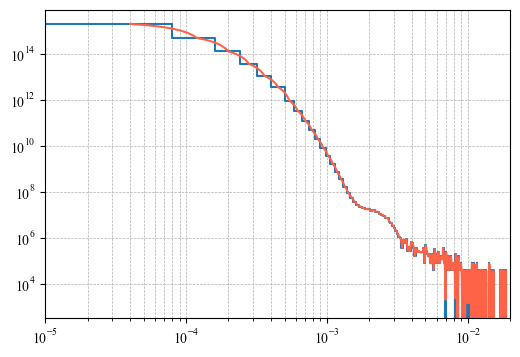

In [3]:
# Run57 load LEE histogram
si_mass_kg = 0.2329e-3

run57 = np.loadtxt('combined_spectra.txt')
bw = run57[1,0]-run57[0,0]
edges = np.append(run57[:,0]-bw/2,run57[-1,0]+bw/2)
edges[0] = 0.
print( len(edges) )
print( len(run57[:,1]) )

fig, ax = plt.subplots(1,figsize=(6,4))
h = Hist1d.from_histogram(run57[:,1]*si_mass_kg,edges)
h.plot()

ax.set_xlim(0.1e-4,2e-2)
ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(lw=0.5,ls='--',which='both')

# make interpolation function to use as well:
lee_func = interpolate.interp1d(h.bin_centers,h.histogram,bounds_error=False,fill_value=0)
e_low, e_high = h.bin_centers[0], 100e-3
en_interp = np.linspace(e_low,e_high, num=10000)
plt.plot(en_interp,lee_func(en_interp),color='tomato')
print('done.')

done.


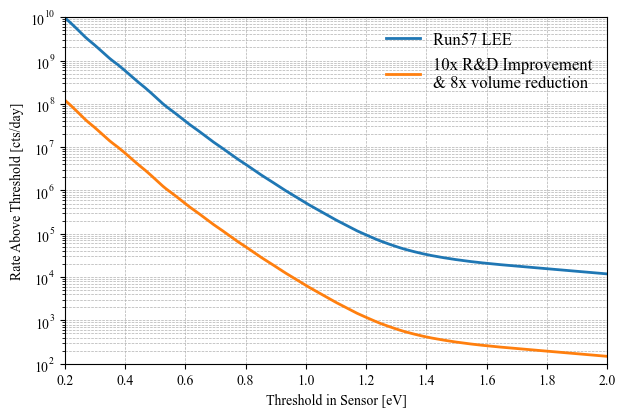

In [40]:
# diagnostic plot: rate above threshold in single device

w = 100e-6 # coincidence window in seconds
scale_factor = 1
lee_scale_factors = [1,0.1/8]
labs = ['Run57 LEE','10x R&D Improvement\n& 8x volume reduction']
fig, ax = plt.subplots(1,figsize=(7,4.5))

for i,sf in enumerate(lee_scale_factors):
    thresholds = np.linspace(0.1e-3,10e-3,num=1000)
    rates_above_threshold = sf*np.asarray([ pdf_integral(lee_func,thres,100e-3,10000) for thres in thresholds ])
    plt.plot(thresholds*1000,rates_above_threshold,lw=2,label=labs[i])

ax.set_xlim(0.2,2)
#ax.xaxis.set_major_locator(MaxNLocator(14))
ax.set_ylim(1e2,1e10)
#ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(lw=0.5,ls='--',which='both')
ax.legend(loc='upper right',frameon=False,ncol=1,fontsize=12)

ax.set_xlabel('Threshold in Sensor [eV]')
ax.set_ylabel('Rate Above Threshold [cts/day]')
#ax.set_title('Total Rate = {:0.3e} cts/day'.format(pile_up_rate))

print('done.')

done.


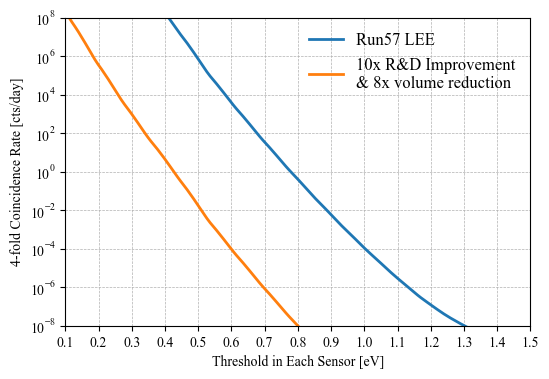

In [30]:
# plot 4-fold pileup rate vs per_device_threshold

w = 100e-6 # coincidence window in seconds
scale_factor = 1
lee_scale_factors = [1,0.1/8]
labs = ['Run57 LEE','10x R&D Improvement\n& 8x volume reduction']
fig, ax = plt.subplots(1,figsize=(6,4))

for i,sf in enumerate(lee_scale_factors):
    thresholds = np.linspace(0.1e-3,10e-3,num=1000)
    rates_above_threshold = np.asarray([ pdf_integral(lee_func,thres,100e-3,10000) for thres in thresholds ])
    pile_up_rates = scale_factor * (sf*rates_above_threshold/24/3600)**4 * w**(4-1) * 3600*24

    plt.plot(thresholds*1000,pile_up_rates,lw=2,label=labs[i])

#ax.set_xlim(thresholds[0]*1000,thresholds[-1]*1000)
ax.set_xlim(0.1,1.5)
ax.xaxis.set_major_locator(MaxNLocator(14))
ax.set_ylim(1e-8,1e8)
#ax.set_xscale('log')
ax.set_yscale('log')
ax.grid(lw=0.5,ls='--',which='both')
ax.legend(loc='upper right',frameon=False,ncol=1,fontsize=12)

ax.set_xlabel('Threshold in Each Sensor [eV]')
ax.set_ylabel('4-fold Coincidence Rate [cts/day]')
#ax.set_title('Total Rate = {:0.3e} cts/day'.format(pile_up_rate))

print('done.')

In [12]:
# settings/parameters:

#max_coinc = 4
#energy_res = 0.2e-3 # keV

ntoys = 100000 #500000000
n_devices = 4
template_bins = 150

per_device_thresholds = np.arange(0.2,1.2,0.2) * 1e-3 # keV
rates_above_threshold = np.asarray([ pdf_integral(lee_func,thres,100e-3,10000) for thres in per_device_thresholds ])

detectors = ['4-1cm2','4-0.5cm2','16-0.5cm2','24-0.5cm2']

print('running with the following thresholds [keV]:')
print(per_device_thresholds)
print('which have the following rates [cts/day]:')
print(rates_above_threshold)
print('')

running with the following thresholds [keV]:
[0.0002 0.0004 0.0006 0.0008 0.001 ]
which have the following rates [cts/day]:
[9.77973022e+09 5.85132140e+08 3.97358370e+07 4.02263773e+06
 5.15627760e+05]



In [15]:
rates_above_threshold[0]

9779730221.19785

device threshold = 2.000e-04 keV; rate above threshold = 9.780e+09 cts/day.
drawing random samples...
finished drawing samples.
min energy of keepers = 8.175e-04 keV

    detector=4-1cm2; scale factor=1.0; LEE scale factor=1.0000.
    -->pileup rate is 1.418e+13 cts/day.
      check of pileup rate = 1.418e+13 cts/day
    Done with this detector config.


    detector=4-0.5cm2; scale factor=1.0; LEE scale factor=0.0125.
    -->pileup rate is 3.463e+05 cts/day.
      check of pileup rate = 3.463e+05 cts/day
    Done with this detector config.


    detector=16-0.5cm2; scale factor=9.0; LEE scale factor=0.0125.
    -->pileup rate is 3.116e+06 cts/day.
      check of pileup rate = 3.116e+06 cts/day
    Done with this detector config.


    detector=24-0.5cm2; scale factor=13.0; LEE scale factor=0.0125.
    -->pileup rate is 4.501e+06 cts/day.
      check of pileup rate = 4.501e+06 cts/day
    Done with this detector config.

device threshold = 4.000e-04 keV; rate above threshold = 5.851e+0

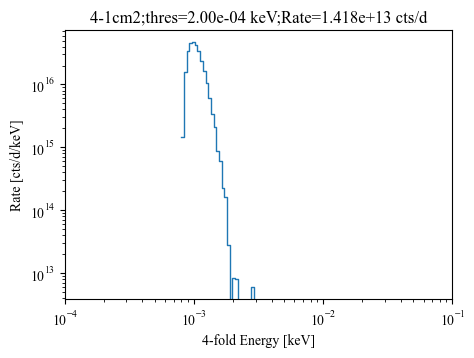

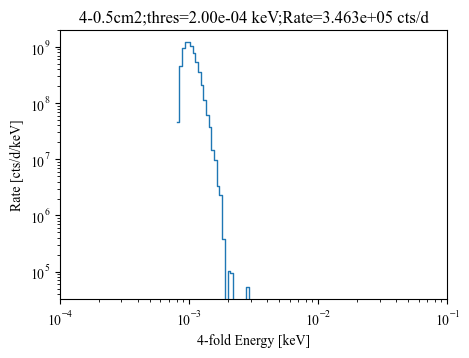

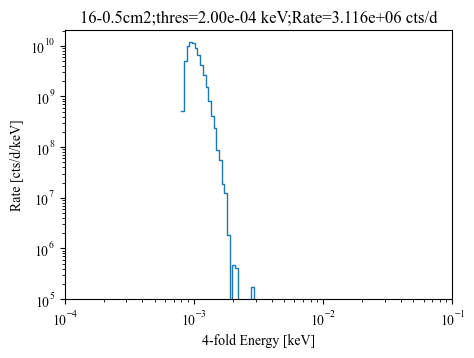

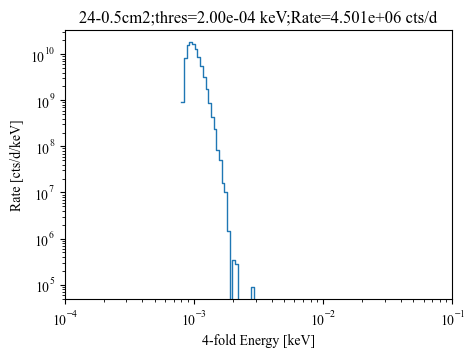

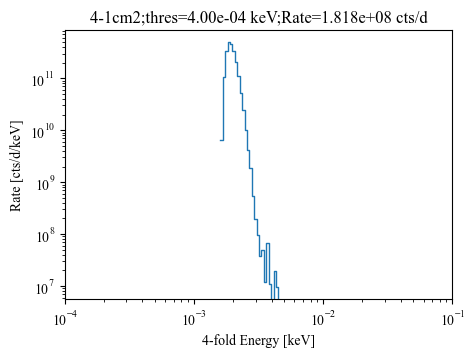

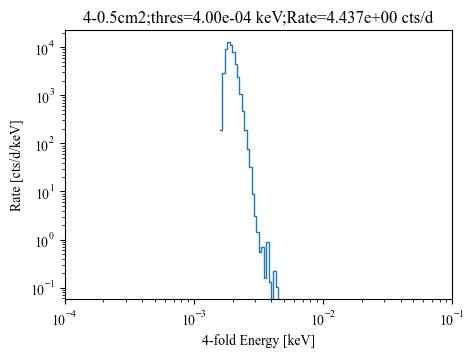

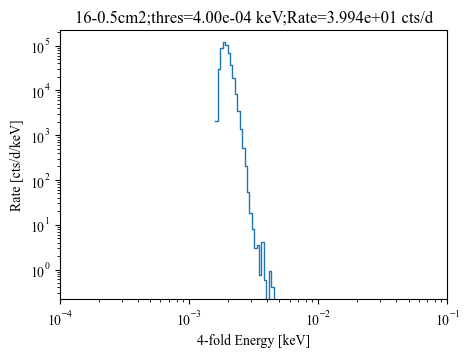

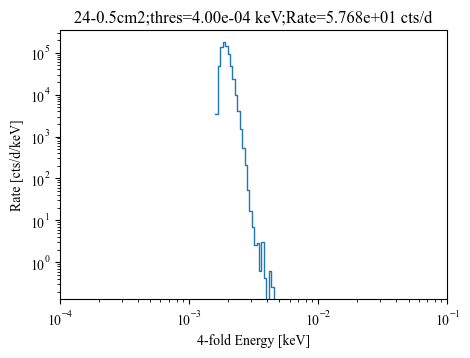

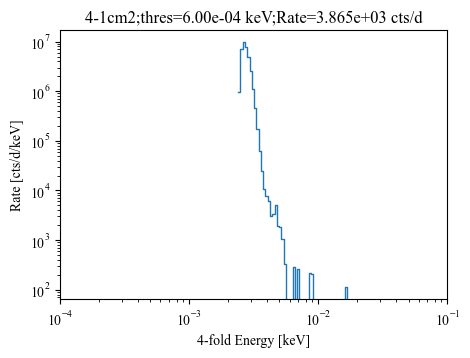

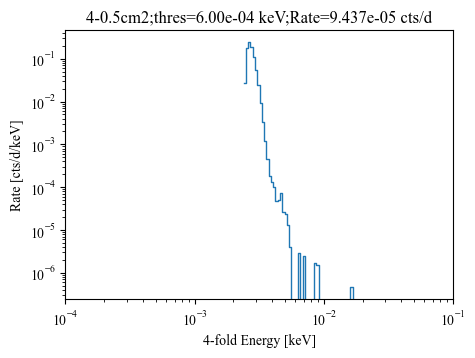

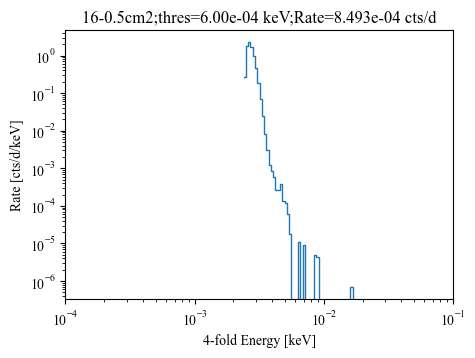

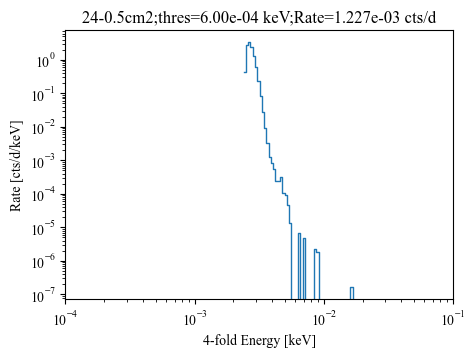

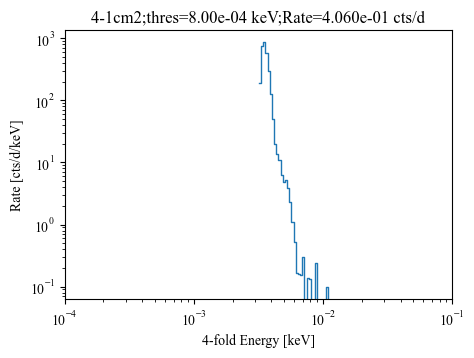

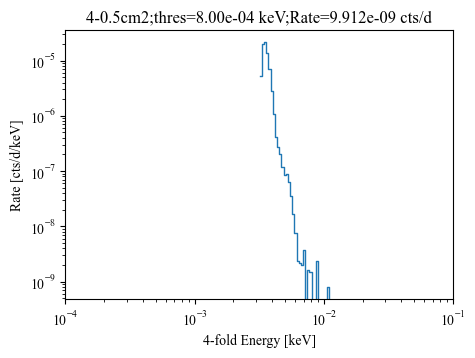

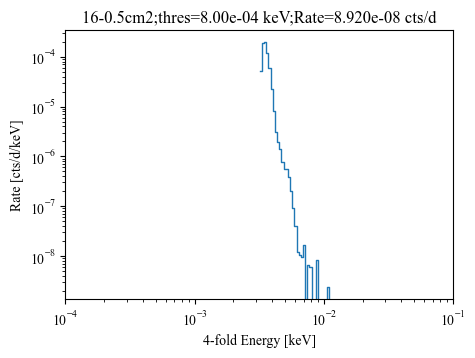

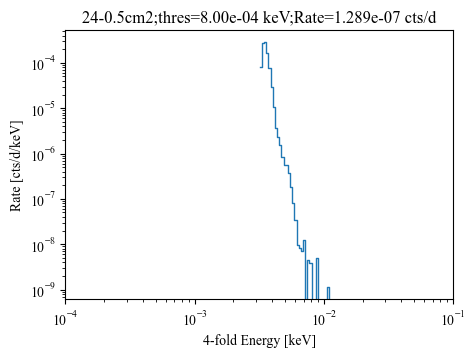

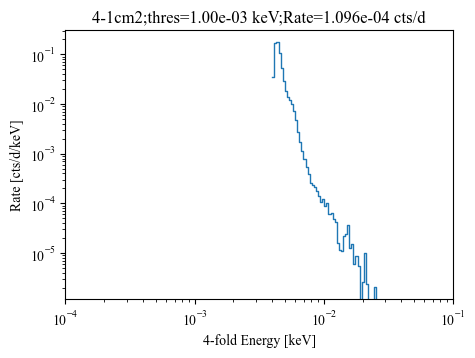

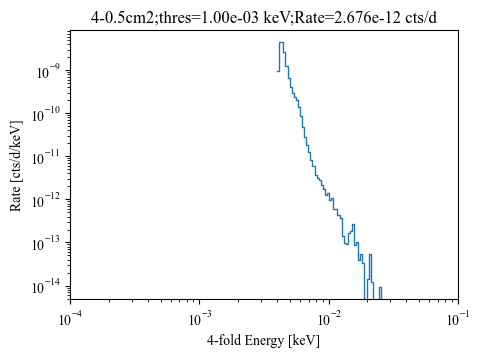

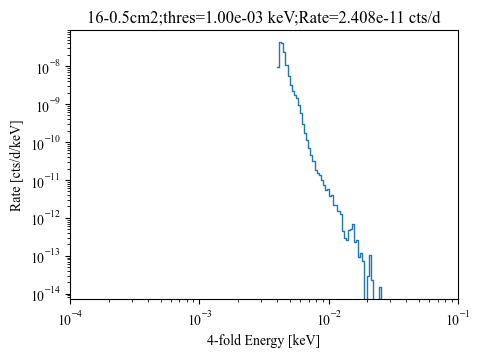

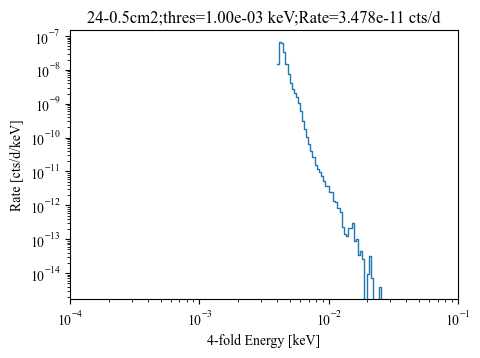

In [25]:
# loop to make templates

plot_check = True
save = False

for i,per_device_threshold in enumerate(per_device_thresholds):

    rate = rates_above_threshold[i]
    print('device threshold = {:0.3e} keV; rate above threshold = {:0.3e} cts/day.'.format(per_device_threshold, rate))
    
    # make new histogram from threshold up:
    cut_idx, cut_val = find_nearest_floor(h.bin_edges, per_device_threshold)
    new_edges = h.bin_edges[cut_idx:]
    new_content = h.histogram[cut_idx:]
    hn = Hist1d.from_histogram(new_content,new_edges)

    print('drawing random samples...')
    # get random samples from hist (memory intensive)
    raw_evts = np.zeros((n_devices,ntoys))
    for n in range(n_devices):
        raw_evts[n,:] = hn.get_random(size=ntoys) #randoms from LEE histogram
    summed_energy = np.sum(raw_evts,axis=0) # summed energy across devices (no threshold)
    raw_evts[np.where(raw_evts<per_device_threshold)] = 0 # sets events below per device threshold to zero
    n_over = np.count_nonzero(raw_evts,axis=0) # gives number of devices above threshold for each event
    keepers = summed_energy[n_over>=n_devices] # summed energy of evts which satisfy coincidence requirement
    print('finished drawing samples.')
    print('min energy of keepers = {:0.3e} keV'.format(min(keepers)))
    
    # make template histogram of the keepers:
    #e_low = per_device_threshold
    e_low = per_device_threshold*n_devices # lowest bin edge at lowest possible summed energy
    e_high = 1
    hnk = Hist1d(keepers,bins=np.geomspace(e_low,e_high,num=template_bins))
    bw = hnk.bin_edges[1::]-hnk.bin_edges[:-1]

    # now loop over different detector configurations
    # each detector config will result in different normalization 
    # of the template histogram
    for d, detector in enumerate(detectors):
        
        scale_factor = 1
        lee_scale_factor = 1
        w = 100e-6
        if detector=='4-1cm2':
            scale_factor = 1
            lee_scale_factor = 1
            w = 100e-6
        if detector=='4-0.5cm2':
            scale_factor = 1
            lee_scale_factor = 0.1/8
            w = 100e-6
        if detector=='16-0.5cm2':
            scale_factor = 9
            lee_scale_factor = 0.1/8
            w = 100e-6
        if detector=='24-0.5cm2':
            scale_factor = 13
            lee_scale_factor = 0.1/8
            w = 100e-6

        print('')
        print('    detector={:s}; scale factor={:.1f}; LEE scale factor={:0.4f}.'.format(detector,scale_factor,lee_scale_factor))
        # pileup rate:
        pile_up_rate = scale_factor * 3600*24 * ( lee_scale_factor * rate/24/3600 )**n_devices * w**(n_devices-1)
        print('    -->pileup rate is {:0.3e} cts/day.'.format(pile_up_rate))
        
        # normalize the template hist to this pileup rate:
        hnk *= pile_up_rate/np.sum(hnk.histogram)
        hnk *= 1/bw
        # check the normalization of that histogram is correct:
        rate_check = np.sum(hnk.histogram * (hnk.bin_edges[1::]-hnk.bin_edges[:-1]))
        print('      check of pileup rate = {:0.3e} cts/day'.format(rate_check))

        if plot_check:
            fig, ax = plt.subplots(1,figsize=(5,3.5))
            hnk.plot(lw=1)
            ax.set_xlim(1e-4,1e-1)
            ax.set_xscale('log')
            ax.set_yscale('log')
            ax.set_xlabel('4-fold Energy [keV]')
            ax.set_ylabel('Rate [cts/d/keV]')
            ax.set_title('{:s};thres={:0.2e} keV;Rate={:0.3e} cts/d'.format(detector,per_device_threshold,pile_up_rate))
        
        if save:
            outname = './Run57_LEE_templates/LEE_bkg_{:s}_{:d}fold_{:0.0f}mus_{:0.2e}keV.txt'.format(detector,n_devices,w/1e-6,per_device_threshold)
            tot = np.column_stack( (hnk.bin_centers, hnk.histogram) )
            np.savetxt(outname,tot,fmt=['%.5e','%0.5e'] ,delimiter=' ', header='energy[keV] evts/day/keV')
        
        print('    Done with this detector config.\n')

print('Done with all thresholds.')

In [10]:
1 * 3600*24 * (1*9.780e9/24/3600)**4 * 100e-6**(3-1)

1.4184505228427211e+17

In [18]:
rates_above_threshold

array([9.77973022e+09, 5.85132140e+08, 3.97358370e+07, 4.02263773e+06,
       5.15627760e+05])

0.0008
rate above 8.000e-04 keV = 7.004e+06 cts/day


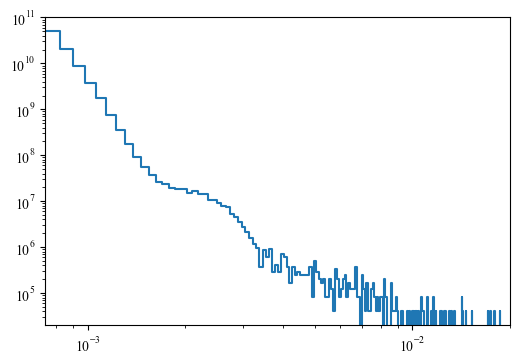

In [31]:
# create a LEE background hist that only has bins above threshold:

max_coinc = 4
energy_res = 0.2e-3 # keV

#per_device_threshold = stats.norm.isf(stats.norm.sf(5)**(1/max_coinc)) * energy_res
per_device_threshold = 0.8e-3
print(per_device_threshold)

cut_idx, cut_val = find_nearest_floor(h.bin_edges, per_device_threshold)
#print(cut_idx, cut_val)
new_edges = h.bin_edges[cut_idx:]
new_content = h.histogram[cut_idx:]
#print(new_edges)

# plot new hist and sample from it
fig, ax = plt.subplots(1,figsize=(6,4))
hn = Hist1d.from_histogram(new_content,new_edges)
hn.plot()

ax.set_xlim(cut_val,2e-2)
ax.set_xscale('log')
ax.set_yscale('log')

# test of sampling 
#randos = hn.get_random(size=100000000)
#hnr = hn.similar_blank_histogram()
#hnr.add(randos)
#scale = hn.n/hnr.n
#hnr.plot(scale_histogram_by=scale)

rate_above_threshold = np.sum(hn.histogram * (hn.bin_edges[1::]-hn.bin_edges[:-1]))
print('rate above {:0.3e} keV = {:0.3e} cts/day'.format(per_device_threshold,rate_above_threshold))


In [5]:
ntoys = 500000000
n_devices = 4
raw_evts = np.zeros((n_devices,ntoys))
for i in range(n_devices):
    raw_evts[i,:] = hn.get_random(size=ntoys) #randoms from LEE histogram

summed_energy = np.sum(raw_evts,axis=0)
raw_evts[np.where(raw_evts<per_device_threshold)] = 0 # sets events below threshold to zero - this should be the *per device threshold*
n_over = np.count_nonzero(raw_evts,axis=0) # gives number of devices above threshold for each event
keepers = summed_energy[n_over>=n_devices] # summed energy of evts which satisfy coincidence requirement
print(per_device_threshold)

0.0008


In [6]:
min(keepers)

0.003201820639397371

In [7]:
rate_above_threshold

7004010.551448344

scale factor =  1
done


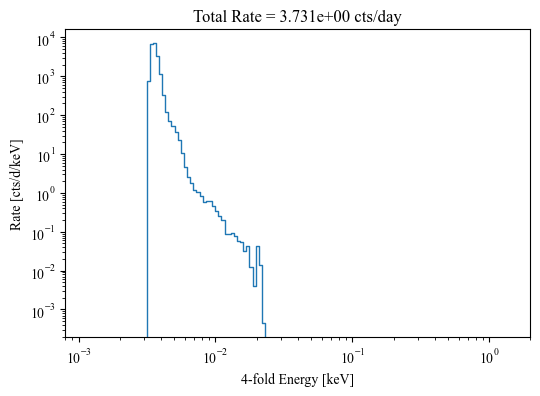

In [8]:
# plot the keepers - normalize to rate

w = 100e-6 # coincidence window in seconds

fig, ax = plt.subplots(1,figsize=(6,4))
#hnk = hn.similar_blank_histogram()
#hnk.add(keepers)
#hnk.plot()

# log bins
e_low = per_device_threshold
e_high = 2
hnk = Hist1d(keepers,bins=np.geomspace(e_low,e_high,num=150))
bw = hnk.bin_edges[1::]-hnk.bin_edges[:-1]

# normalize based on what arrangement of sensors we are
# assuming:
detector = '4-1cm2' 
#detector = '16-0.5cm2'
#detector = '24-1cm2'
scale_factor = 1
lee_scale_factor = 1
if detector=='4-1cm2':
    scale_factor = 1
    lee_scale_factor = 1
if detector=='16-0.5cm2':
    scale_factor = 9
    lee_scale_factor = 0.1/8 # 0.1 from R&D, 8 from simple volume reduction
    # run this with he_gain = 0.3
if detector=='24-1cm2':
    scale_factor = 13
    lee_scale_factor = 0.1/2 # 0.1 from R&D, 2 from simple volume reduction (thinner sensor)
    # run this with he_gain = 0.3

print('scale factor = ',scale_factor)
# pileup rate:
pile_up_rate = scale_factor * (lee_scale_factor*rate_above_threshold/24/3600)**n_devices * w**(n_devices-1) * 3600*24

# normalize hist:
hnk *= pile_up_rate/np.sum(hnk.histogram)
hnk *= 1/bw

hnk.plot(lw=1)

ax.set_xlim(e_low,e_high)
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('4-fold Energy [keV]')
ax.set_ylabel('Rate [cts/d/keV]')
ax.set_title('Total Rate = {:0.3e} cts/day'.format(pile_up_rate))
print('done')

In [9]:
# check the normalization of that histogram is correct:
rate_check = np.sum(hnk.histogram * (hnk.bin_edges[1::]-hnk.bin_edges[:-1]))
print('check of pileup rate is {:0.3e} cts/day'.format(rate_check))

check of pileup rate is 3.731e+00 cts/day


In [10]:
save = True
if save:
    outname = './Run57_LEE_templates/LEE_bkg_{:s}_{:d}fold_{:0.0f}mus_{:0.2e}keV.txt'.format(detector,n_devices,w/1e-6,per_device_threshold)
    tot = np.column_stack( (hnk.bin_centers, hnk.histogram) )
    np.savetxt(outname,tot,fmt=['%.5e','%0.5e'] ,delimiter=' ', header='energy[keV] evts/day/keV')

print('done.')# generate toys from m devices with n-fold coincidence

done.


In [57]:
print(raw_evts)
print(summed_energy)
print(n_over)
print(keepers)

[[0.         0.00045731 0.00056612 ... 0.         0.00056144 0.        ]
 [0.         0.         0.         ... 0.         0.00048145 0.        ]
 [0.         0.         0.         ... 0.00039893 0.         0.        ]
 [0.         0.00039989 0.         ... 0.         0.         0.        ]]
[0.00139419 0.00157992 0.00162531 0.00149861 0.00191282 0.00189159
 0.00145941 0.00153652 0.001643   0.00149629 0.00177216 0.00155622
 0.00185143 0.00145384 0.00160533 0.00167514 0.0016862  0.0015485
 0.00155047 0.00165913 0.00147813 0.00146903 0.00173773 0.0014671
 0.00144929 0.00157838 0.00154471 0.00200769 0.00133218 0.00155624
 0.00183707 0.00159783 0.00183779 0.00165781 0.00153659 0.00169209
 0.00166158 0.00189626 0.00137787 0.00139525 0.00150783 0.00149898
 0.00153992 0.00150511 0.00171459 0.00180429 0.00155323 0.0016061
 0.00146379 0.00171329 0.00201575 0.00176064 0.00156651 0.00151228
 0.00187709 0.00146705 0.00139178 0.00142145 0.00144483 0.00163622
 0.00194337 0.00146053 0.00156586 0.0017

In [49]:
raw_evts[np.where(raw_evts<per_device_threshold)] = 0
print(raw_evts)

[[0.00045878 0.         0.         0.         0.         0.
  0.         0.00040117 0.         0.         0.00043249 0.
  0.         0.00042214 0.00039872 0.         0.         0.00043683
  0.         0.         0.00041922 0.         0.         0.
  0.         0.         0.         0.         0.00042026 0.
  0.         0.00044799 0.         0.         0.00044211 0.
  0.00055088 0.         0.         0.00041894 0.         0.0004748
  0.         0.         0.00049807 0.00055438 0.         0.00041595
  0.         0.00044632 0.         0.00058498 0.         0.
  0.00043089 0.         0.         0.         0.         0.
  0.         0.00071477 0.00043181 0.         0.         0.00041803
  0.         0.         0.         0.00045029 0.         0.
  0.         0.         0.         0.         0.         0.00042348
  0.         0.         0.00042787 0.         0.00052264 0.
  0.         0.         0.         0.         0.         0.00050918
  0.         0.         0.         0.         0.     

In [26]:
def find_nearest(array, value):
    array = np.asarray(array)
    idx = (np.abs(array - value)).argmin()
    return idx, array[idx]

def find_nearest_floor(array, value):
    array = np.asarray(array)
    #idx = (np.floor(np.abs(array - value))).argmin()
    idx = array.searchsorted(value, 'right') - 1
    return idx, array[idx]

In [15]:
value = 0.15
np.floor(np.abs(a - value)).argmin()

0

In [25]:
a[np.where(a<value)][-1]

0.2

In [23]:
a<value

array([ True,  True, False, False, False])

In [31]:
a = np.array([0.1, 0.2, 1.4, 2.3, 4.5])

value = 1.5

print( find_nearest(a,value) )
print( find_nearest_floor(a,value) )


(2, 1.4)
(2, 1.4)


In [2]:
def power(x,amplitude,abs_power):
    return amplitude * x**(-1*abs_power)

def shifted_power(x,a,b):
    '''
    normalized
    '''
    return (x+a)**(-b) * (b-1) * a**(b-1)

def shifted_power_cdf(x,a,b):
    '''
    normalized
    '''
    return 1-( (x+a)/a )**(1-b)

def expo(x, a):
    '''
    normalized
    '''
    return a * np.exp(-x * a)

def expo_cdf(x,a):
    return 1 - np.exp(-x * a)

def pdf_integral(pdf,e_low,e_high,npts):
    '''
    assumes 'pdf' is a lambda function
    '''
    #en_interp = np.geomspace(e_low,e_high, num=npts)
    en_interp = np.linspace(e_low,e_high, num=npts)
    return np.trapz( pdf(en_interp), x=en_interp)

In [12]:

e_low = 1e-6
e_high = 1
npts = 100000

a1 = 1/4.137e-4
a2 = 1/3.808e-3
pdf = lambda x: expo(x,a1)
#pdf = lambda x: shifted_power(x,2,5.7)
rate = pdf_integral(pdf,e_low,e_high,npts)

print('{:0.3f} cts/day'.format(rate))


0.998 cts/day


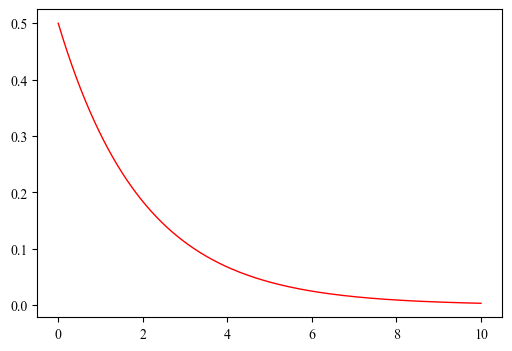

In [4]:
fig, ax = plt.subplots(1,figsize=(6,4))
#h = Hist1d(raw_evts[0,:],bins=np.geomspace(e_low,e_high,num=500))
#bw = h.bin_edges[1::]-h.bin_edges[:-1]
#h *= 1/np.sum(h.histogram)
#h *= 1/bw
#h.plot(lw=1,label='{}-fold'.format(c))

en_interp = np.geomspace(e_low,e_high, num=npts)
#plt.plot(en_interp,shifted_power_cdf(en_interp,2,5.7),lw=1,color='red')
plt.plot(en_interp,expo(en_interp,1/2),lw=1,color='red')

#ax.set_xlim(e_low*0.5,e_high)
#ax.set_xscale('log')
#ax.set_yscale('log')

In [16]:
# copied version from DarkLim:

def expo_sampling(a, nsamples=1000):
    """
    quickly sample rands from exponential function with
    form: exp(-a*x)
    """
    inv_cdf = lambda x: -np.log(1-x)/a
    samples = np.random.rand(nsamples)
    return inv_cdf(samples)

def shifted_power_sampling(a,b, nsamples=1000):
    """
    quickly sample rands from shifted power law function with
    form: (x+a)**(-b) * (b-1) * a**(b-1)
    """
    
    cdf = lambda x: 1-( (x+a)/a )**(1-b)
    inv_cdf = lambda x: a*(1-cdf(x))**(1/(1-b)) - a
    samples = np.random.rand(nsamples)
    return inv_cdf(samples)

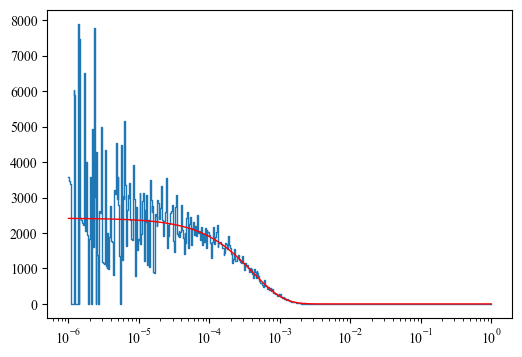

In [15]:
# test expo sampling

e_low = 1e-6
e_high = 1
npts = 100000

a1 = 1/4.137e-4
#a2 = 1/3.808e-3
pdf = lambda x: expo(x,a1)


fig, ax = plt.subplots(1,figsize=(6,4))

evts = expo_sampling(a1,nsamples=10000)

h = Hist1d(evts,bins=np.geomspace(e_low,e_high,num=500))
bw = h.bin_edges[1::]-h.bin_edges[:-1]
h *= 1/np.sum(h.histogram)
h *= 1/bw
h.plot(lw=1)

en_interp = np.geomspace(e_low,e_high, num=npts)
#plt.plot(en_interp,shifted_power_cdf(en_interp,2,5.7),lw=1,color='red')
plt.plot(en_interp,pdf(en_interp),lw=1,color='red')

#ax.set_xlim(e_low,e_high)
ax.set_xscale('log')
#ax.set_yscale('log')

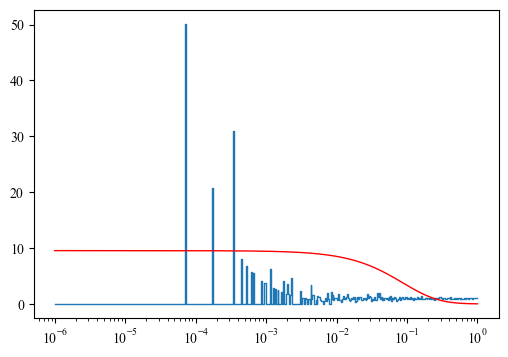

In [17]:
# test shifted power sampling

e_low = 1e-6
e_high = 1
npts = 100000

a = 0.5
b = 5.77
pdf = lambda x: shifted_power(x,a,b)

fig, ax = plt.subplots(1,figsize=(6,4))

evts = shifted_power_sampling(a,b,nsamples=10000)

h = Hist1d(evts,bins=np.geomspace(e_low,e_high,num=500))
bw = h.bin_edges[1::]-h.bin_edges[:-1]
h *= 1/np.sum(h.histogram)
h *= 1/bw
h.plot(lw=1)

en_interp = np.geomspace(e_low,e_high, num=npts)
#plt.plot(en_interp,shifted_power_cdf(en_interp,2,5.7),lw=1,color='red')
plt.plot(en_interp,pdf(en_interp),lw=1,color='red')

#ax.set_xlim(e_low,e_high)
ax.set_xscale('log')
#ax.set_yscale('log')

In [3]:
# copied version from DarkLim:

def pdf_sampling(function, xrange, nsamples=1000, npoints=10000, normalize_cdf=True):
    """
    Produces randomly sampled values based on the arbitrary PDF defined
    by `function`, done using inverse transform sampling.

    Parameters
    ----------
    function : FunctionType
        The 1D probability density function to be randomly sampled from.
    xrange : array_like
        A 1D array of length 2 that defines the range over which the PDF
        in `function` is defined. Outside of this range, it is assumed that
        the PDF is zero.
    nsamples : int, optional
        The number of random samples that we wish to create from the PDF
        defined by `function`.
    npoints : int, optional
        The number of points to use in the numerical integration to evaluate
        the CDF of `function`. This is also the number of points used in the
        interpolation of the inverse of the CDF.
    normalize_cdf : bool, optional
        Boolean value to normalize the CDF or not. If True, the CDF is normalized
        by the PDF area. If False, no normalization is done.

    Returns
    -------
    rvs : ndarray
        The random samples that were taken from the inputted PDF defined by
        `function`. This is a 1D array of length `nsamples`.

    Raises
    ------
    TypeError
        If inputted `function` is not of FunctionType

    Notes
    -----
    For a discussion of inverse transform sampling, see the Wikipedia page:
        https://en.wikipedia.org/wiki/Inverse_transform_sampling

    """

    if not isinstance(function, types.FunctionType):
        raise TypeError("Inputted variable function is not FunctionType.")

    x = np.linspace(xrange[0], xrange[1], num=npoints)
    pdf = function(x)

    cdf = integrate.cumtrapz(pdf, x=x, initial=0.0)

    if normalize_cdf:
        cdf /= cdf[-1]

    inv_cdf = interpolate.interp1d(cdf, x)

    samples = np.random.rand(nsamples)

    return inv_cdf(samples)

In [3]:
# modified for specific PDFs

def pdf_sampling(function, xrange, nsamples=1000, npoints=10000, normalize_cdf=True):
    """
    Produces randomly sampled values based on the arbitrary PDF defined
    by `function`, done using inverse transform sampling.

    Parameters
    ----------
    function : FunctionType
        The 1D probability density function to be randomly sampled from.
    xrange : array_like
        A 1D array of length 2 that defines the range over which the PDF
        in `function` is defined. Outside of this range, it is assumed that
        the PDF is zero.
    nsamples : int, optional
        The number of random samples that we wish to create from the PDF
        defined by `function`.
    npoints : int, optional
        The number of points to use in the numerical integration to evaluate
        the CDF of `function`. This is also the number of points used in the
        interpolation of the inverse of the CDF.
    normalize_cdf : bool, optional
        Boolean value to normalize the CDF or not. If True, the CDF is normalized
        by the PDF area. If False, no normalization is done.

    Returns
    -------
    rvs : ndarray
        The random samples that were taken from the inputted PDF defined by
        `function`. This is a 1D array of length `nsamples`.

    Raises
    ------
    TypeError
        If inputted `function` is not of FunctionType

    Notes
    -----
    For a discussion of inverse transform sampling, see the Wikipedia page:
        https://en.wikipedia.org/wiki/Inverse_transform_sampling

    """

    if not isinstance(function, types.FunctionType):
        raise TypeError("Inputted variable function is not FunctionType.")

    x = np.linspace(xrange[0], xrange[1], num=npoints)
    pdf = function(x)

    cdf = integrate.cumtrapz(pdf, x=x, initial=0.0)

    if normalize_cdf:
        cdf /= cdf[-1]

    inv_cdf = interpolate.interp1d(cdf, x)

    samples = np.random.rand(nsamples)

    return inv_cdf(samples)

In [2]:
E_LOW_GLOBAL_KEV = 1e-6
E_HIGH_GLOBAL_KEV = 100.
NPTS_GLOBAL = int(1e5)

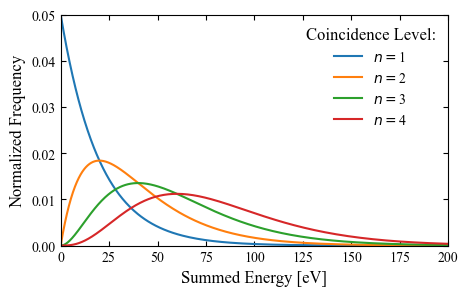

In [18]:
fig, ax = plt.subplots(1,figsize=(5,3))

lam = 1/20
ks = np.arange(1,5)
x = np.geomspace(1e-3,1e3,1000)

for k in ks:

    dist = stats.erlang.pdf(x,a=k,loc=0,scale=1/lam)
    dist2 = stats.expon.pdf(x,loc=0,scale=1/lam)

    plt.plot(x, dist,label=r'$n=$'+'{:d}'.format(k))
    
#plt.plot(x, dist2,'r--',label='Expo. Dist')
ax.set_xlim(0,200)
ax.set_ylim(0,0.05)
ax.tick_params(which="both", direction="in", right=True, top=True)
ax.legend(loc='upper right',frameon=False,title='Coincidence Level:',title_fontsize=12)
ax.set_xlabel('Summed Energy [eV]',fontsize=12)
ax.set_ylabel('Normalized Frequency',fontsize=12)

plt.savefig('./pretty_plots/erlang.png',facecolor='white',bbox_inches='tight')

In [2]:
def power_bkgd(x,amplitude,abs_power):
    return amplitude * x**(-1*abs_power)
pdf = lambda x: power_bkgd(x,1.4e-8, 5.77)+power_bkgd(x,0.107, 2.72)

en_interp = np.geomspace(1.865e-3,10, num=10000)
rate = np.trapz( pdf(en_interp), x=en_interp)
print('{:0.1f} cts/day'.format(rate))

33731.1 cts/day


In [8]:
# generate ntoys

def power_bkgd(x,amplitude,abs_power):
    return amplitude * x**(-1*abs_power)
pdf = lambda x: power_bkgd(x,1.4e-8, 5.77)+power_bkgd(x,0.107, 2.72)

def pdf_integral(pdf,e_low,e_high,npts):
    '''
    assumes 'pdf' is a lambda function
    '''
    en_interp = np.geomspace(e_low,e_high, num=npts)
    return np.trapz( pdf(en_interp), x=en_interp)

w = 100e-6 # coincidence window in seconds

energy_res = 0.373e-3 # energy resolution in keV
nsigma = 5
threshold = nsigma*energy_res

e_low = 0.5e-3 #keV - determined by lowest per device threshold considered
e_high = 2 #keV
npts = 100000

print('threshold = {:0.3e} keV'.format(threshold))
print('threshold = {:0.3e} eV'.format(threshold*1000))



threshold = 1.865e-03 keV
threshold = 1.865e+00 eV


In [6]:

#print('integral from {} to {} keV = {:.2e} evts/day'.format(bins[0],bins[-1],integral))
#print('= {:0.2e} evts/s'.format(integral/24/3600))

In [11]:
# generate toys from m devices with n-fold coincidence

save = False

show_sample_plot = False

var_threshold = True
per_device_threshold = 0.
#devices = np.array([1,2,3,4])

ntoys = 1000000
devices = np.array([2])

res_dict = {}

for i,m in enumerate(devices): # loop over total number of devices

    if m<3:
        ntoys = int(2e8)
    elif m==3:
        ntoys = int(1e8) #int(5e8)
    elif m==4:
        ntoys = int(1e8)
        
    print('')
    print('Considering',m,'total devices')

    # consider coincidence levels from 1 to number of devices
    # highest coincidence level corresponds to lowest threshold
    # here we adjust the lower bound of the random sampling 
    # range based on threshold to improve efficiency 
    coinc = np.arange(1,m+1)
    max_coinc = np.max(coinc)
    lowest_threshold = stats.norm.isf(stats.norm.sf(5)**(1/max_coinc)) * energy_res
    sample_e_low = 0.3*lowest_threshold
    print('\t Sampling with e_low = {:0.3f} eV'.format(sample_e_low*1000))
    # simulate events in all devices:
    raw_evts = np.zeros((m,ntoys))
    for d in range(m): # simulate ntoys in each device
        raw_evts[d,:] = pdf_sampling( pdf, (sample_e_low, e_high), npoints=npts, nsamples=ntoys )
    
    if show_sample_plot:
        fig, ax = plt.subplots(1,figsize=(6,4))
        h = Hist1d(raw_evts[0,:],bins=np.geomspace(e_low,e_high,num=500))
        bw = h.bin_edges[1::]-h.bin_edges[:-1]
        h *= 1/np.sum(h.histogram)
        h *= 1/bw
        h.plot(lw=1,label='{}-fold'.format(c))
        plt.plot(h.bin_centers,pdf(h.bin_centers)*(1/pdf_integral(pdf,e_low,e_high,npts)),lw=1,color='red', label='Run 47 Power-Law\nLEE Model')
        ax.set_xlim(e_low*0.5,e_high)
        ax.set_xscale('log')
        ax.set_yscale('log')

        
    summed_energy = np.sum(raw_evts,axis=0) # total energy in all devices
    
    # impose threshold depending on coincidence level:
    for c in coinc:
        print('Coincidence level =',c)
        if var_threshold:
            nsigma = stats.norm.isf(stats.norm.sf(5)**(1/c))
        else:
            nsigma = 5
        per_device_threshold = nsigma * energy_res
        threshold = c*per_device_threshold

        print('\tThreshold is {:0.2f} sigma = {:0.3f} eV in each device'.format(nsigma,per_device_threshold*1000))
        print('\t Total energy threshold = {:0.3f} eV'.format(threshold*1000))

        # make a copy of un-thresholded events
        # the array 'evts' will get modified for each coincidence level
        evts = np.copy(raw_evts)
        
        evts[np.where(evts<per_device_threshold)] = 0 # sets events below threshold to zero - this should be the *per device threshold*
        n_over = np.count_nonzero(evts,axis=0) # gives number of devices above threshold for each event        
        keepers = summed_energy[n_over>=c] # summed energy of evts which satisfy coincidence requirement
        print('\t{:0.3f}% of evts survive coincidence requirement'.format(100.*len(keepers)/ntoys))
        
        # get rate above device threshold in single device:
        rate = pdf_integral(pdf,per_device_threshold,e_high,npts)/24/3600 # want in counts/s/kg
        print('\tRate from {:.4f} to {:.4f} keV = {:.2e} evts/d/kg'.format(per_device_threshold,e_high,rate*3600*24))
        
        # pileup rate:
        term1 = special.factorial(m)/special.factorial(m-c)
        term2 = rate**c * w**(c-1)
        pile_up_rate = term1*term2*3600*24
        print('\t{}-fold pileup rate = {:.2e} evts/d/kg'.format(c,pile_up_rate))
                
        res_dict[str(m)+'_'+str(c)+'_summede'] = keepers
        res_dict[str(m)+'_'+str(c)+'_rate'] = pile_up_rate
            
print('done.')


Considering 2 total devices
	 Sampling with e_low = 0.366 eV
Coincidence level = 1
	Threshold is 5.00 sigma = 1.865 eV in each device
	 Total energy threshold = 1.865 eV
	0.092% of evts survive coincidence requirement
	Rate from 0.0019 to 2.0000 keV = 3.37e+04 evts/d/kg
	1-fold pileup rate = 6.75e+04 evts/d/kg
Coincidence level = 2
	Threshold is 3.27 sigma = 1.220 eV in each device
	 Total energy threshold = 2.440 eV
	0.001% of evts survive coincidence requirement
	Rate from 0.0012 to 2.0000 keV = 2.38e+05 evts/d/kg
	2-fold pileup rate = 1.31e+02 evts/d/kg
done.


2-device, 1-fold hist rate check: 6.75e+04 cts/d
2-device, 2-fold hist rate check: 1.31e+02 cts/d
done.


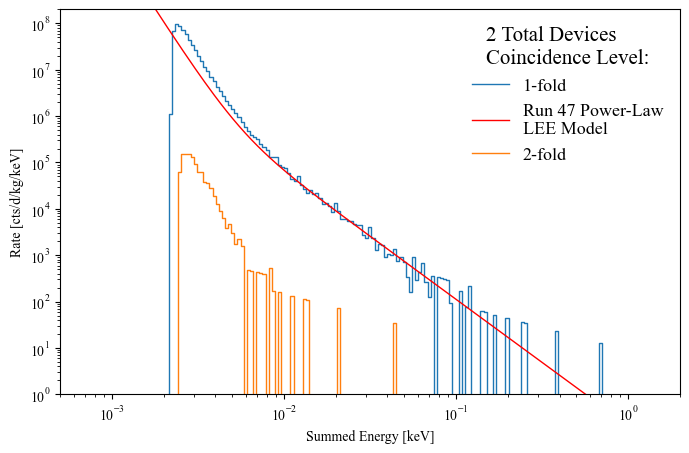

In [12]:
# plot results separately so we can play with binning
save = False

for i,m in enumerate(devices):
    fig, ax = plt.subplots(1,figsize=(8,5))
    coinc = np.arange(1,m+1)
    for c in coinc:

        sum_energy = res_dict[str(m)+'_'+str(c)+'_summede']

        # log bins
        h = Hist1d(sum_energy,bins=np.geomspace(e_low,e_high,num=200))
        bw = h.bin_edges[1::]-h.bin_edges[:-1]

        #h = Hist1d(sum_energy,bins=npts,range=(e_low,e_high))
        #bw = h.bin_centers[1]-h.bin_centers[0]

        #normalize:
        pile_up_rate = res_dict[str(m)+'_'+str(c)+'_rate']
        h *= pile_up_rate/np.sum(h.histogram)
        h *= 1/bw
        
        
        h.plot(lw=1,label='{}-fold'.format(c))
        #h.plot(scale_histogram_by=1,lw=1,label='{}-fold'.format(c),normed=True)
        #h.plot(scale_histogram_by=1/bw,lw=1,label='{}-fold MC w/threshold'.format(c),normed=True)

        #if m==1 and c==1: #overlay pdf in this case
        if c==1: #overlay pdf in this case
            plt.plot(h.bin_centers,m*pdf(h.bin_centers),lw=1,color='red', label='Run 47 Power-Law\nLEE Model')
        
        #x = np.geomspace(e_low,e_high,10000)
        #dist = pdf(x)
        #plt.plot(x, dist/np.trapz(dist, x=x),label='Summed Power Law')

        #ax.set_title('{:d} Total Devices'.format(m))
        #ax.set_xlim(e_low,e_high)
        ax.set_xlim(e_low,e_high)
        ax.set_xscale('log')
        ax.set_ylim(1,2e8)
        ax.set_yscale('log')
        ax.legend(loc='upper right', title='{:d} Total Devices\nCoincidence Level:'.format(m), frameon=False,ncol=1,fontsize=13,title_fontsize=15)
        #ax.legend(loc='upper right', title='{:0.1e} keV threshold in each device'.format(threshold),ncol=2)
        ax.set_xlabel('Summed Energy [keV]')
        ax.set_ylabel('Rate [cts/d/kg/keV]')

        print('{}-device, {}-fold hist rate check: {:0.2e} cts/d'.format(m,c, np.sum(h.histogram*bw) ))

        if save:
            outname = './LEE_templates/LEE_bkg_{:d}device_{:d}fold_{:0.0f}mus.txt'.format(m,c,w/1e-6)
            tot = np.column_stack( (h.bin_centers, h.histogram) )
            np.savetxt(outname,tot,fmt=['%.5e','%0.5e'] ,delimiter=' ', header='energy[keV] evts/day/keV/kg')

print('done.')# generate toys from m devices with n-fold coincidence

done.


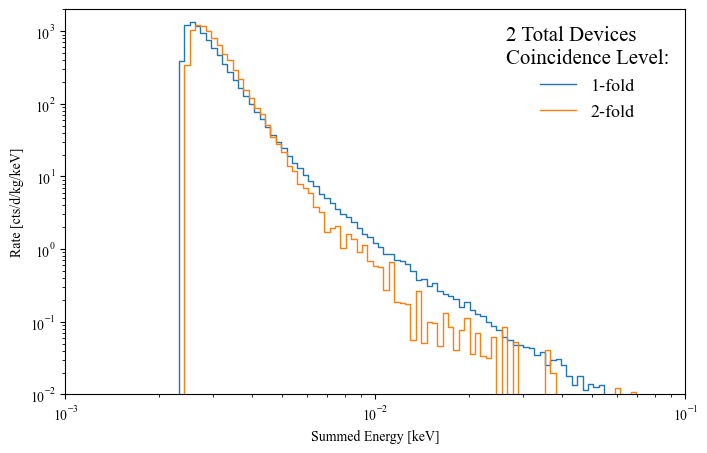

In [10]:
# test if distribtions have same shape...

m = 2

#c_thres = np.array([1.865e-3,1.220e-3,0.925e-3])

c_thres = np.array([1.865e-3,1.220e-3])

fig, ax = plt.subplots(1,figsize=(8,5))

hists = []
for i,c in enumerate([1,2]):

        if c==1:
            sum_energy = res_dict[str(m)+'_'+str(c)+'_summede']
        else:
            #sum_energy = (c_thres[0]/(c*c_thres[i])) * res_dict[str(m)+'_'+str(c)+'_summede']
            sum_energy = res_dict[str(m)+'_'+str(c)+'_summede']
            
        # log bins
        h = Hist1d(sum_energy,bins=np.geomspace(e_low,e_high,num=200))
        bw = h.bin_edges[1::]-h.bin_edges[:-1]

        h *= 1/np.sum(h.histogram)
        h *= 1/bw
                
        h.plot(lw=1,label='{}-fold'.format(c))



ax.set_xlim(e_low,e_high)
ax.set_xscale('log')
ax.set_ylim(1e-2,2e3)
ax.set_xlim(1e-3,1e-1)
ax.set_yscale('log')
ax.legend(loc='upper right', title='{:d} Total Devices\nCoincidence Level:'.format(m), frameon=False,ncol=1,fontsize=13,title_fontsize=15)
#ax.legend(loc='upper right', title='{:0.1e} keV threshold in each device'.format(threshold),ncol=2)
ax.set_xlabel('Summed Energy [keV]')
ax.set_ylabel('Rate [cts/d/kg/keV]')

        

print('done.')# generate toys from m devices with n-fold coincidence

In [18]:
h.bin_edges

array([1.00000000e-03, 1.04999000e-03, 1.09998000e-03, ...,
       4.99990002e+00, 4.99995001e+00, 5.00000000e+00])

In [19]:
h.bin_edges[1::]

array([1.04999000e-03, 1.09998000e-03, 1.14997000e-03, ...,
       4.99990002e+00, 4.99995001e+00, 5.00000000e+00])

In [20]:
h.bin_edges[:-1]

array([1.00000000e-03, 1.04999000e-03, 1.09998000e-03, ...,
       4.99985003e+00, 4.99990002e+00, 4.99995001e+00])

In [21]:
h.bin_edges[1::]-h.bin_edges[:-1]

array([4.999e-05, 4.999e-05, 4.999e-05, ..., 4.999e-05, 4.999e-05,
       4.999e-05])

In [15]:
print(bw)

4.999000000000019e-05


In [6]:
keepers.max()

0.011623914633628048

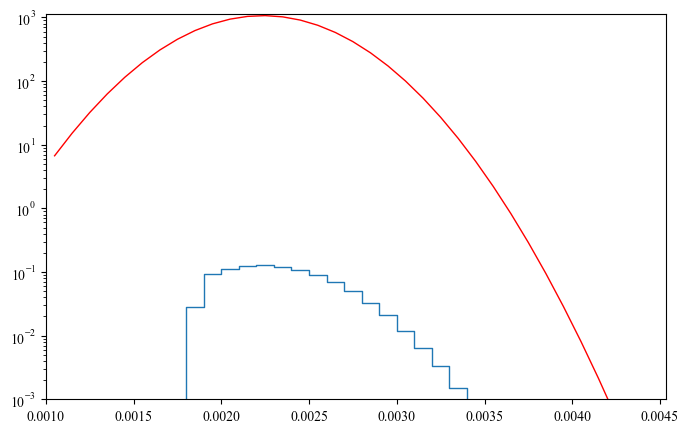

In [39]:
# save dummy data to test loading and interpolation inside SensEst:
save = False

mu = 6*energy_res
sigma = energy_res
s = np.random.normal(mu, sigma, 1000000)
pts = s[s>threshold]

fig, ax = plt.subplots(1,figsize=(8,5))
h = Hist1d(pts,bins=npts,range=(e_low,e_high))
bw = h.bin_centers[1]-h.bin_centers[0]
h = h*(1/bw)
#h.plot(scale_histogram_by=1,lw=1,normed=True)
#h.plot(scale_histogram_by=1/bw,lw=1,normed=True)
h.plot(lw=1,normed=True)

bins = h.bin_centers
vals = h.histogram

plt.plot(bins, 1/(sigma * np.sqrt(2 * np.pi))*np.exp(-(bins - mu)**2 / (2 * sigma**2) ),lw=1, color='r')

ax.set_xlim(e_low,pts.max()*1.1)
#ax.set_xscale('log')
ax.set_ylim(0.001,None)
ax.set_yscale('log')

if save:
        #outname = 'LEE_bkg_{:d}device_{:d}fold_{:0.0f}mus.txt'.format(n_devices,n,window/1e-6)
        outname = 'testdata.txt'
        tot = np.column_stack( (bins, vals) )
        np.savetxt(outname,tot,fmt=['%.5e','%0.5e'] ,delimiter=' ', header='energy[keV] evts/day/keV')

In [43]:
# load testdata and make interp func:
testin = np.loadtxt('testdata.txt',skiprows=1)
print(np.shape(testin))

print(type(testin))

(100000, 2)
<class 'numpy.ndarray'>


In [ ]:
interp_func = interpolate.interp1d(testin[:,0],testin[:,1])

fig, ax = plt.subplots(1,figsize=(8,5))

In [21]:
# generate toys from m devices with n-fold coincidence

sum_all_energy = False

devices = np.array([1,2,3,4])

summed_energy = {}

for i,m in enumerate(devices): # loop over total number of devices
    print('device #',m')
    # simulate events in all devices:
    evts = np.zeros((m,ntoys))
    for d in range(m): # simulate ntoys in each device
        evts[d,:] = pdf_sampling( pdf, (e_low, e_high), npoints=npts, nsamples=ntoys )
    
    #print( evts[0,:10] )
    evts[np.where(evts<threshold)] = 0 # sets events below threshold to zero - this should be the *per device threshold*
    #print( evts[0,:10] )
    summed_energy[m] = np.sum(evts,axis=0) # sum energy accross devices
    
    #coinc = np.arange(2,m+1)
    #print('{} devices. coinc levels considered are '.format(m),coinc)
    
    #for j,n in enumerate(coinc):
    #    print('coinc level is ',n)
    #    
    #    # apply threshold to the first n channels
    #    for d in range(n):
    #        evts[d,:]
print('done.')

[0.00890226 0.00193366 0.01079027 0.00163338 0.00467823 0.00907259
 0.00135301 0.00893067 0.00977215 0.00495709]
[0.00890226 0.00193366 0.01079027 0.         0.00467823 0.00907259
 0.         0.00893067 0.00977215 0.00495709]
[0.0028602  0.00841154 0.00671738 0.00380692 0.00989576 0.00402931
 0.01010037 0.00149107 0.00516816 0.00806071]
[0.0028602  0.00841154 0.00671738 0.00380692 0.00989576 0.00402931
 0.01010037 0.         0.00516816 0.00806071]
[0.0034989  0.007528   0.00916924 0.00358474 0.00168518 0.00645742
 0.00662174 0.00107128 0.00932454 0.00543961]
[0.0034989  0.007528   0.00916924 0.00358474 0.         0.00645742
 0.00662174 0.         0.00932454 0.00543961]
[0.01026771 0.00553212 0.00389359 0.00553916 0.01084236 0.00924688
 0.00944472 0.00727594 0.00176651 0.00539641]
[0.01026771 0.00553212 0.00389359 0.00553916 0.01084236 0.00924688
 0.00944472 0.00727594 0.         0.00539641]
done.


Text(0.5, 0, 'Summed Energy [keV]')

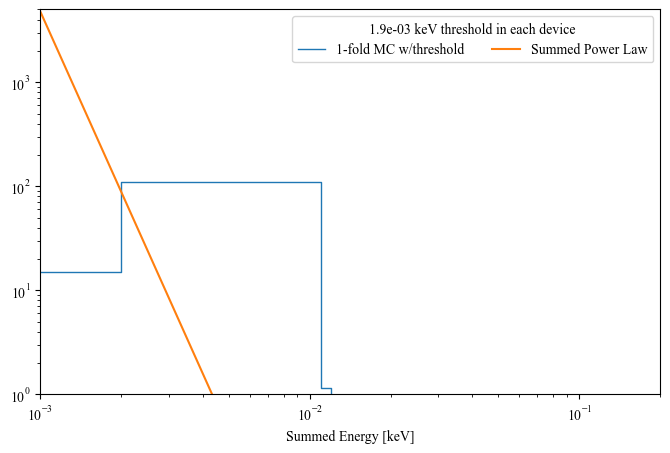

In [20]:
# histogram the simulated toys with PDF for single device
fig, ax = plt.subplots(1,figsize=(8,5))

m=1
h = Hist1d(summed_energy[m],bins=10000,range=(e_low,e_high))
bw = h.bin_centers[1]-h.bin_centers[0]
h.plot(scale_histogram_by=1/bw,lw=1,label='{}-fold MC w/threshold'.format(m),normed=True)

x = np.geomspace(e_low,e_high,10000)
#x = np.linspace(e_low,e_high,10000)

dist = pdf(x)
plt.plot(x, dist/np.trapz(dist, x=x),label='Summed Power Law')
        

ax.set_xlim(e_low,0.2)
ax.set_xscale('log')
ax.set_ylim(1,None)
ax.set_yscale('log')
ax.legend(loc='upper right', title='{:0.1e} keV threshold in each device'.format(threshold),ncol=2)
ax.set_xlabel('Summed Energy [keV]')

1
2
3
4


Text(0.5, 0, 'Summed Energy [keV]')

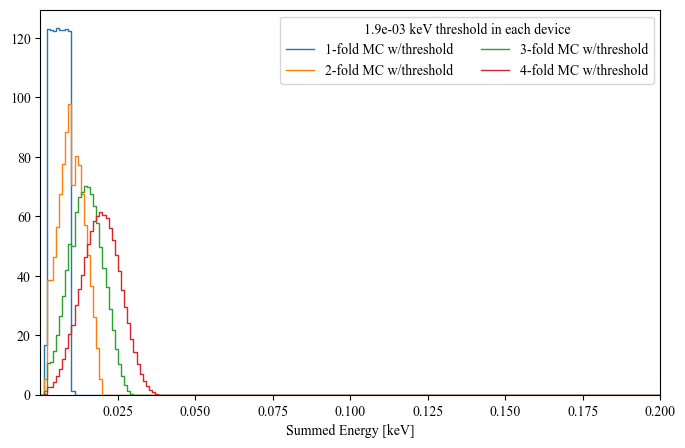

In [13]:
# histogram the simulated toys
fig, ax = plt.subplots(1,figsize=(8,5))

for i,m in enumerate(devices):
    h = Hist1d(summed_energy[m],bins=10000,range=(e_low,e_high))
    bw = h.bin_centers[1]-h.bin_centers[0]
    h.plot(scale_histogram_by=1/bw,lw=1,label='{}-fold MC w/threshold'.format(m),normed=True)

#x = np.geomspace(e_low,e_high,10000)
#x = np.linspace(e_low,e_high,10000)
#for k in devices:
#    dist = stats.erlang.pdf(x,a=k,loc=0,scale=1/lam)
#    plt.plot(x, dist/np.trapz(dist, x=x),label='Erlang, k={:d}'.format(k))
        

ax.set_xlim(e_low,0.2)
#ax.set_xscale('log')
ax.set_ylim(0,None)
ax.legend(loc='upper right', title='{:0.1e} keV threshold in each device'.format(threshold),ncol=2)
ax.set_xlabel('Summed Energy [keV]')

In [25]:
test = pdf_sampling( pdf, (e_low, e_high), npoints=npts, nsamples=ntoys )
print(test)
test[np.where(test<0.02)] = 0
print(test)

[0.01814909 0.08861029 0.02425482 ... 0.00364906 0.00120441 0.01921873]
[0.         0.08861029 0.02425482 ... 0.         0.         0.        ]


In [24]:
test

array([0.06928629, 0.        , 0.        , ..., 0.        , 0.        ,
       0.        ])

10000


Text(0.5, 0, 'Summed Energy [keV]')

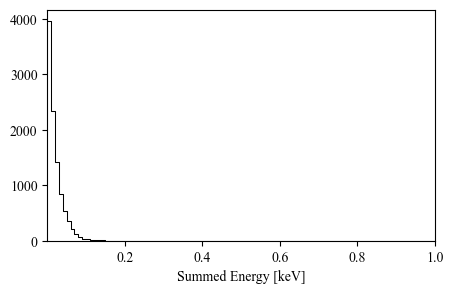

In [6]:
# histogram the simulated toys
fig, ax = plt.subplots(1,figsize=(5,3))

h = Hist1d(evts_sim,bins=npts,range=(e_low,e_high))
h.plot(color='black',lw=0.75)

print(h.n)

ax.set_xlim(e_low,1)
#ax.set_xscale('log')
ax.set_ylim(0,None)
#ax.legend(loc='upper right')
ax.set_xlabel('Summed Energy [keV]')

In [4]:
# Detector info setup

#n_devices = 4
#coinc = 2
#window = 100e-6 # s

mass_det = 0.00115 # mass in kg
time_elapsed = 1000 # days
efficiency = 1.0

tm = 'He' # target name

energy_res = 0.373e-3 # energy resolution in keV
#threshold = coinc*5*energy_res

print('detector mass is {} kg = {} g'.format(mass_det,mass_det*1000))
print('run time is {} days'.format(time_elapsed))
print('exposure is {} kg-days'.format(mass_det*time_elapsed))
#print('threshold = {:0.3f} eV'.format(threshold*1000))
#print('assuming {:d}-fold coincidence amongst {:d} devices in a {:0.1f} microsecond window'.format(coinc,n_devices,window/1e-6))

detector mass is 0.00115 kg = 1.15 g
run time is 1000 days
exposure is 1.15 kg-days


In [ ]:
SE = darklim.sensitivity.SensEst(mass_det, time_elapsed, eff=efficiency, tm=tm)

SE.reset_sim()
#SE.add_flat_bkgd(1) # flat background of 1 DRU
#SE.add_nfold_lee_bkgd(m=4,n=2,w=window)
SE.add_nfold_lee_bkgd(m=n_devices,n=coinc,w=window)

In [ ]:
# test the nfold LEE function

fig, ax = plt.subplots(1,figsize=(6,4))

save = False

#bins = np.linspace(0.0001,1,1000)
bins = np.geomspace(1e-3,1,1000)

n_devices = 1
#coinc = np.arange(1,5)
coinc = np.array([1])
window = 100e-6# s
for n in coinc:
    
    print('{}-fold coincidence:'.format(n))
    model = darklim.sensitivity.n_fold_lee(bins,m=n_devices,n=n,w=window)
    
    integral = np.trapz(model,x=bins)
    print('integral from {} to {} keV = {:.2e} evts/day'.format(bins[0],bins[-1],integral))
    print('= {:0.2e} evts/s'.format(integral/24/3600))
    print(' ')
    
    plt.plot(bins,model,label='{:d}-fold'.format(n))
    
    if save:
        outname = 'LEE_bkg_{:d}device_{:d}fold_{:0.0f}mus.txt'.format(n_devices,n,window/1e-6)
        tot = np.column_stack( (bins, model) )
        np.savetxt(outname,tot,fmt=['%.5e','%0.5e'] ,delimiter=' ', header='energy[keV] evts/day/keV')
    
#lhe_mass = 0.010 # kg
#ax.axhline(1*lhe_mass,label='1 DRU in 10g LHe'.format(n),color='black',ls='--') # 1 DRU=1 evt/keV/d/kg
#plt.plot(bins,
    
ax.set_ylabel('evts/keV/day')
ax.set_xlabel('Total Energy [keV]')
ax.set_xlim(1e-6,1)
#ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(None,1e11)
ax.legend(loc='upper right',frameon=False,title='{:d} devices total;'.format(n_devices)+' Coinc. level in {:0.0f}'.format(window*1e6)+r'$\mu$s window:',ncol=3)

In [ ]:
# p-values to demonstrate the sf and isf functions:
p_sig = np.zeros(6) # p values
sigma = np.zeros(6) # sigmas
for sig in range(1,6):
    p_sig[sig-1] = stats.norm.sf(sig)
    sigma[sig-1] = stats.norm.isf(p_sig[sig-1])
    print('p-value for {:d} sigma is {:0.5e}'.format(sig,p_sig[sig-1]))
    print(' ->check that sigma is {:0.2f}\n'.format(sigma[sig-1]))